In [3]:
sns.color_palette("hls", 9)

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.7178666666666667, 0.33999999999999997),
 (0.6554666666666664, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.3712),
 (0.33999999999999997, 0.86, 0.7178666666666667),
 (0.33999999999999997, 0.6554666666666664, 0.86),
 (0.3712, 0.33999999999999997, 0.86),
 (0.7178666666666661, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.6554666666666664)]

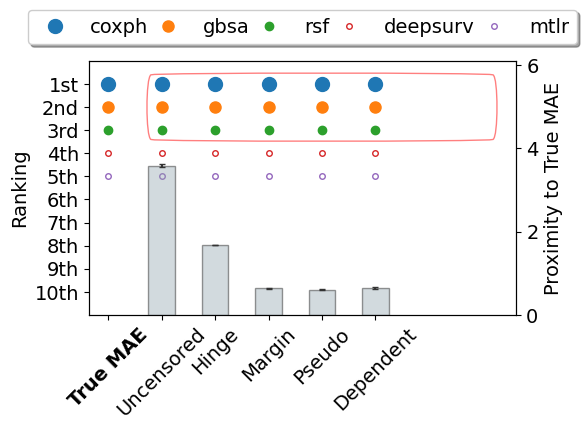

In [39]:
# the figure to present the results
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
from matplotlib.figure import figaspect
from utility.data import get_dataset_info, map_dataset_name, map_strategy_name
import config as cfg

matplotlib_style = 'default'
import matplotlib.pyplot as plt; plt.style.use(matplotlib_style)
plt.rcParams.update({'axes.labelsize': 'medium',
                     'axes.titlesize': 'medium',
                     'font.size': 14.0})

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

results = pd.read_csv(Path.joinpath(cfg.RESULTS_DIR, "dependent.csv"))
metrics = ["CIHarrell", "CIUno", "CIDepIPCW", "IBSIPCW", "IBSDepBG",
            "MAEUncens", "MAEHinge", "MAEMargin" ,"MAEPseudo", "MAEDepBG"]

# Scale metrics by percentage
cols_to_scale = ["CITrue", "CIHarrell", "CIUno", "CIDepIPCW", "IBSTrue", "IBSIPCW", "IBSDepBG"]
results[cols_to_scale] = results[cols_to_scale] * 100

datasets = ["metabric", "seer_stomach", "seer_liver"]
strategies = ["original", "top_5", "top_10", "random_25"]
model_names = ["coxph", "gbsa", "rsf", "deepsurv", "mtlr"]

for idx, dataset in enumerate(datasets):
    results = results.loc[results['Dataset'] == dataset] # select dataset
    results = results.loc[results['Strategy'] == "original"]
    results = results.loc[results['Seed'] == 0]

    metrics_names = ['True MAE', 'Uncensored', 'Hinge', 'Margin', 'Pseudo', 'Dependent']
    ranking = ['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th']
    
    rank_idx = results['MAETrue'].values.argsort()
    true_mae = results['MAETrue'].values[rank_idx]
    uncensor = results['MAEUncens'].values[rank_idx]
    hinge = results['MAEHinge'].values[rank_idx]
    margin = results['MAEMargin'].values[rank_idx]
    pseudo = results['MAEPseudo'].values[rank_idx]
    dependent = results['MAEDepBG'].values[rank_idx]

    difference = [np.abs((uncensor - true_mae)).mean(), np.abs((hinge - true_mae)).mean(), np.abs((margin - true_mae)).mean(), np.abs((pseudo - true_mae)).mean(), np.abs((dependent - true_mae)).mean()]
    std = [(uncensor - true_mae).std(), (hinge - true_mae).std(), (margin - true_mae).std(), (pseudo - true_mae).std(), (dependent - true_mae).std()]

    x = np.arange(len(metrics_names))
    w, h = figaspect(2.5/3.1)
    fig, ax = plt.subplots(figsize=(w,h))
    ax_bar = ax.twinx()
    size = [10, 8, 6, 4, 4, 3, 3, 3, 3, 3]
    for i in range(len(model_names)):
        order = np.array([i, uncensor.argsort()[i], hinge.argsort()[i], margin.argsort()[i], pseudo.argsort()[i], dependent.argsort()[i]])
        if i >= 3:
            ax.plot(x, order + 1, 'o', label=model_names[i], ms=size[i], markerfacecolor='none', color=color_list[i])
        else:
            ax.plot(x, order + 1, 'o', label=model_names[i], ms=size[i], color=color_list[i])
    ax.set_xticks(x)
    ax.set_xticklabels([metrics_names[i] for i in range(len(metrics_names))], rotation=45)[0].set_weight("bold")
    ax.set_yticks(np.arange(1, 11))
    ax.set_yticklabels([rank for rank in ranking])
    ax.set_ylim(11, 0)
    #ax.set_xlabel(f'{dataset}, {censor_dist}, {censor_rate:.2f}% Censoring Rate')
    ax.set_ylabel('Ranking')
    # rect = patches.Rectangle((0.7, 0.5), 6.6, 3, linewidth=1, edgecolor='r', facecolor='none')
    rect = patches.FancyBboxPatch((0.9, 0.7), 6.2, 2.6, linewidth=1, edgecolor='r', facecolor='none', alpha=0.5, boxstyle=patches.BoxStyle("round4", pad=0.2))
    ax.add_patch(rect)

    x = np.arange(1, len(metrics_names))
    ax_bar.bar(x, difference, yerr=std, align='center', width=0.5, linewidth=1, alpha=0.4, ecolor='#333333', capsize=2, color='#90a4ae', edgecolor='black')
    ax_bar.set_ylabel('Proximity to True MAE')
    ax_bar.set_ylim(0, 1.7 * max(difference))

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.24),
              ncol=5, fancybox=True, shadow=True,columnspacing=0.)
    # ax.grid(axis='y')
    plt.tight_layout()
    plt.show()
    #plt.savefig('Figs/results/' + file_name + '.png', dpi=400)
    break